**CELL 1: ENVIRONMENT SETUP & LIBRARY INSTALLATION**

In [47]:
!pip install -q xgboost scikit-learn pandas numpy scipy matplotlib seaborn joblib

import os, time, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix
)

warnings.filterwarnings('ignore')
np.random.seed(42)
os.makedirs("artifacts", exist_ok=True)

# Direct local file check (uses your uploaded CSV file)
DATA_PATH = "creditcard.csv" if os.path.exists("creditcard.csv") else "/content/creditcard.csv"

df_raw = pd.read_csv(DATA_PATH).dropna().reset_index(drop=True)
df_raw['Class'] = df_raw['Class'].astype(int)

total_tx = len(df_raw)
fraud_tx = int(df_raw['Class'].sum())
genuine_tx = total_tx - fraud_tx

print("=" * 65)
print(f"Total Transactions Ingested : {total_tx:,}")
print(f"Genuine Transactions (0)    : {genuine_tx:,} ({(genuine_tx/total_tx)*100:.3f}%)")
print(f"Fraud Transactions (1)      : {fraud_tx:,} ({(fraud_tx/total_tx)*100:.3f}%)")
print("=" * 65)
print("✅ [Cell 1/8] Environment & Dataset Ready.")

Total Transactions Ingested : 284,807
Genuine Transactions (0)    : 284,315 (99.827%)
Fraud Transactions (1)      : 492 (0.173%)
✅ [Cell 1/8] Environment & Dataset Ready.


**Cell 2: Dataset Class Imbalance Diagram**

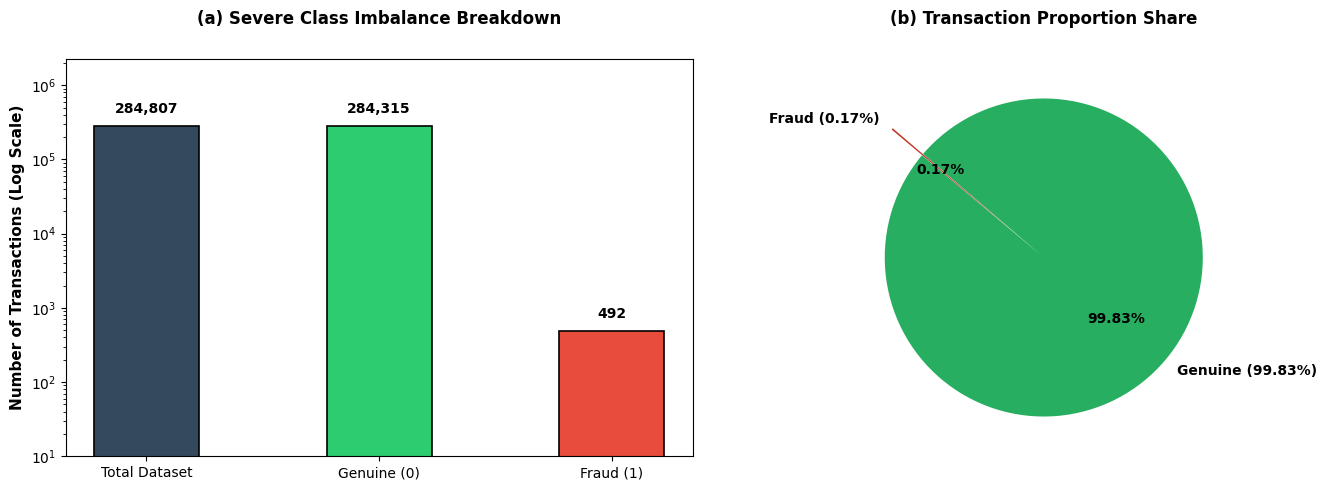

✅ [Cell 2/8] Diagram 1 Generated and Saved with clean spacing.


In [48]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Graph A: Volume Comparison (Log-Scale) with proper spacing
categories = ['Total Dataset', 'Genuine (0)', 'Fraud (1)']
counts = [total_tx, genuine_tx, fraud_tx]
colors = ['#34495e', '#2ecc71', '#e74c3c']

bars = ax[0].bar(categories, counts, color=colors, width=0.45, edgecolor='black', linewidth=1.2)
ax[0].set_yscale('log')
ax[0].set_ylim(bottom=10, top=max(counts) * 8)  # Adds head-room so labels don't collide
ax[0].set_ylabel('Number of Transactions (Log Scale)', fontsize=11, fontweight='bold')
ax[0].set_title('(a) Severe Class Imbalance Breakdown', fontsize=12, fontweight='bold', pad=25)

for bar in bars:
    yval = bar.get_height()
    ax[0].text(
        bar.get_x() + bar.get_width() / 2.0,
        yval * 1.35,
        f'{yval:,}',
        ha='center',
        va='bottom',
        fontweight='bold',
        fontsize=10
    )

# Graph B: Class Share Pie
ax[1].pie(
    [genuine_tx, fraud_tx],
    labels=[f'Genuine ({(genuine_tx/total_tx)*100:.2f}%)', f'Fraud ({(fraud_tx/total_tx)*100:.2f}%)'],
    colors=['#27ae60', '#c0392b'],
    explode=(0, 0.25),
    autopct='%1.2f%%',
    startangle=140,
    textprops={'fontweight': 'bold'}
)
ax[1].set_title('(b) Transaction Proportion Share', fontsize=12, fontweight='bold', pad=25)

plt.tight_layout()
plt.savefig("artifacts/diagram_1_class_distribution.png", dpi=300)
plt.show()
print("✅ [Cell 2/8] Diagram 1 Generated and Saved with clean spacing.")

**CELL 3: ROBUST SCALING & 60/40 STREAMING SPLIT**

In [49]:
from sklearn.model_selection import train_test_split

df_proc = df_raw.copy()
if "Time" in df_proc.columns:
    df_proc = df_proc.drop(columns=["Time"])

scaler = RobustScaler()
df_proc["Scaled_Amount"] = scaler.fit_transform(df_proc[["Amount"]])
df_proc = df_proc.drop(columns=["Amount"])
joblib.dump(scaler, "artifacts/robust_scaler.joblib")

# Stratified 60% Reference Baseline | 40% Live Production Stream
df_ref, df_prod = train_test_split(
    df_proc, test_size=0.40, stratify=df_proc["Class"], random_state=42
)
df_ref = df_ref.reset_index(drop=True)
df_prod = df_prod.reset_index(drop=True)

grp1_cols = [f"V{i}" for i in range(1, 10)]
grp2_cols = [f"V{i}" for i in range(10, 20)]
grp3_cols = [f"V{i}" for i in range(20, 29)] + ["Scaled_Amount"]
all_cols = grp1_cols + grp2_cols + grp3_cols

pos_weight = (len(df_ref) - df_ref["Class"].sum()) / df_ref["Class"].sum()

print(f"Reference Training Set (df_ref) : {df_ref.shape[0]:,} records (Frauds: {df_ref['Class'].sum()})")
print(f"Live Streaming Set     (df_prod): {df_prod.shape[0]:,} records (Frauds: {df_prod['Class'].sum()})")
print(f"Imbalance Weight Ratio          : {pos_weight:.2f}")
print("✅ [Cell 3/8] Stratified Partitioning Complete.")

Reference Training Set (df_ref) : 170,884 records (Frauds: 295)
Live Streaming Set     (df_prod): 113,923 records (Frauds: 197)
Imbalance Weight Ratio          : 578.27
✅ [Cell 3/8] Stratified Partitioning Complete.


**Cell 4: Decoupled Sub-Model Baseline Training**

In [50]:
X_ref = df_ref.drop(columns=["Class"])
y_ref = df_ref["Class"].values

print("🚀 [1/3] Training Sub-Model 1: Random Forest (Features V1-V9)...")
t0 = time.time()
m1 = RandomForestClassifier(n_estimators=60, max_depth=6, class_weight="balanced", random_state=42, n_jobs=-1).fit(X_ref[grp1_cols], y_ref)
print(f"   Done in {time.time()-t0:.2f}s | Saved -> artifacts/submodel_1_rf.joblib")
joblib.dump(m1, "artifacts/submodel_1_rf.joblib")

print("🚀 [2/3] Training Sub-Model 2: XGBoost (Features V10-V19)...")
t0 = time.time()
m2 = XGBClassifier(n_estimators=60, max_depth=4, scale_pos_weight=pos_weight, eval_metric="logloss", random_state=42, n_jobs=-1).fit(X_ref[grp2_cols], y_ref)
print(f"   Done in {time.time()-t0:.2f}s | Saved -> artifacts/submodel_2_xgb.joblib")
joblib.dump(m2, "artifacts/submodel_2_xgb.joblib")

print("🚀 [3/3] Training Sub-Model 3: Decision Tree (Features V20-V28 + Amount)...")
t0 = time.time()
m3 = DecisionTreeClassifier(max_depth=6, class_weight="balanced", random_state=42).fit(X_ref[grp3_cols], y_ref)
print(f"   Done in {time.time()-t0:.2f}s | Saved -> artifacts/submodel_3_dt.joblib")
joblib.dump(m3, "artifacts/submodel_3_dt.joblib")

def predict_ensemble(model1, model2, model3, data, weights=[0.30, 0.45, 0.25]):
    p1 = np.nan_to_num(model1.predict_proba(data[grp1_cols])[:, 1], nan=0.0)
    p2 = np.nan_to_num(model2.predict_proba(data[grp2_cols])[:, 1], nan=0.0)
    p3 = np.nan_to_num(model3.predict_proba(data[grp3_cols])[:, 1], nan=0.0)
    final_prob = (weights[0] * p1) + (weights[1] * p2) + (weights[2] * p3)
    return final_prob, (final_prob >= 0.50).astype(int)

print("✅ [Cell 4/8] Initial Sub-Model Registry Initialized.")

🚀 [1/3] Training Sub-Model 1: Random Forest (Features V1-V9)...
   Done in 41.98s | Saved -> artifacts/submodel_1_rf.joblib
🚀 [2/3] Training Sub-Model 2: XGBoost (Features V10-V19)...
   Done in 0.97s | Saved -> artifacts/submodel_2_xgb.joblib
🚀 [3/3] Training Sub-Model 3: Decision Tree (Features V20-V28 + Amount)...
   Done in 3.22s | Saved -> artifacts/submodel_3_dt.joblib
✅ [Cell 4/8] Initial Sub-Model Registry Initialized.


**Cell 5: Baseline Performance Audit & Comparison Diagram**

                   Precision  Recall  F1-Score
Sub-Model 1 (RF)      0.2478  0.9356    0.3918
Sub-Model 2 (XGB)     0.6317  1.0000    0.7743
Sub-Model 3 (DT)      0.0153  0.8949    0.0300
Weighted Ensemble     0.7610  0.9932    0.8618


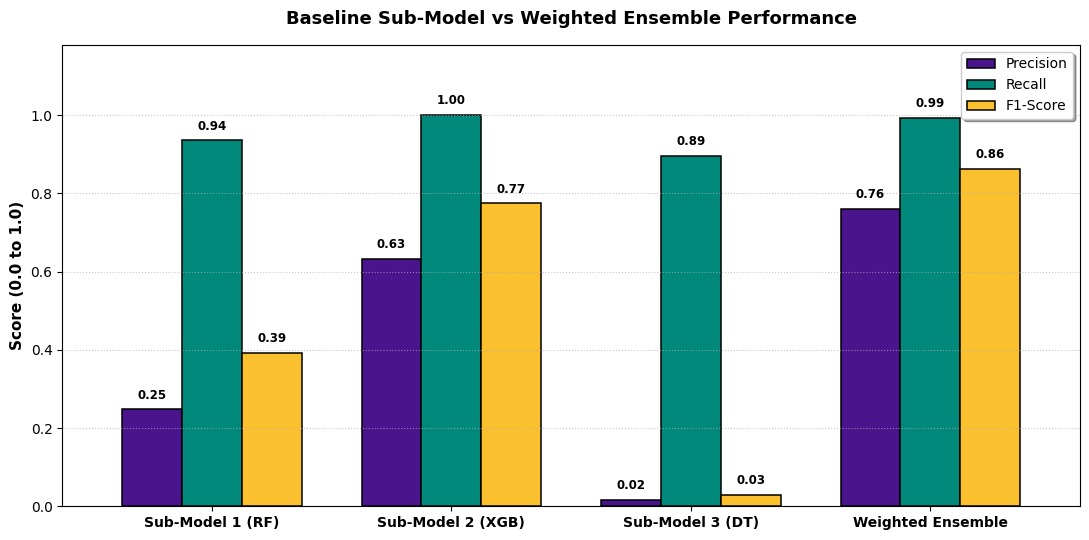

✅ [Cell 5/8] Baseline Audit & Diagram 2 Complete.


In [51]:
p1_ref = m1.predict_proba(X_ref[grp1_cols])[:, 1]
p2_ref = m2.predict_proba(X_ref[grp2_cols])[:, 1]
p3_ref = m3.predict_proba(X_ref[grp3_cols])[:, 1]
prob_ens, pred_ens = predict_ensemble(m1, m2, m3, X_ref)

base_scores = {
    'Sub-Model 1 (RF)': [
        precision_score(y_ref, (p1_ref >= 0.5).astype(int), zero_division=0),
        recall_score(y_ref, (p1_ref >= 0.5).astype(int), zero_division=0),
        f1_score(y_ref, (p1_ref >= 0.5).astype(int), zero_division=0),
    ],
    'Sub-Model 2 (XGB)': [
        precision_score(y_ref, (p2_ref >= 0.5).astype(int), zero_division=0),
        recall_score(y_ref, (p2_ref >= 0.5).astype(int), zero_division=0),
        f1_score(y_ref, (p2_ref >= 0.5).astype(int), zero_division=0),
    ],
    'Sub-Model 3 (DT)': [
        precision_score(y_ref, (p3_ref >= 0.5).astype(int), zero_division=0),
        recall_score(y_ref, (p3_ref >= 0.5).astype(int), zero_division=0),
        f1_score(y_ref, (p3_ref >= 0.5).astype(int), zero_division=0),
    ],
    'Weighted Ensemble': [
        precision_score(y_ref, pred_ens, zero_division=0),
        recall_score(y_ref, pred_ens, zero_division=0),
        f1_score(y_ref, pred_ens, zero_division=0),
    ],
}

base_df = pd.DataFrame(base_scores, index=['Precision', 'Recall', 'F1-Score']).T
print(base_df.round(4).to_string())

# Diagram 2: Baseline Models Comparison with full 0.0 - 1.15 scale
fig, ax = plt.subplots(figsize=(11, 5.5))
base_df.plot(
    kind='bar',
    ax=ax,
    color=['#4a148c', '#00897b', '#fbc02d'],
    edgecolor='black',
    linewidth=1.1,
    width=0.75,
)

ax.set_title(
    'Baseline Sub-Model vs Weighted Ensemble Performance',
    fontsize=13,
    fontweight='bold',
    pad=15,
)
ax.set_ylabel('Score (0.0 to 1.0)', fontsize=11, fontweight='bold')
ax.set_ylim(0.0, 1.18)  # Full range from 0 to 1 so no bars get cut off
ax.set_xticklabels(base_df.index, rotation=0, fontweight='bold')
ax.grid(axis='y', linestyle=':', alpha=0.7)
ax.legend(loc='upper right', frameon=True, shadow=True)

# Add exact value labels on top of every bar
for p in ax.patches:
  val = p.get_height()
  if val > 0.001:
    ax.annotate(
        f'{val:.2f}',
        (p.get_x() + p.get_width() / 2.0, val + 0.02),
        ha='center',
        va='bottom',
        fontsize=8.5,
        fontweight='bold',
        rotation=0,
    )

plt.tight_layout()
plt.savefig('artifacts/diagram_2_baseline_models.png', dpi=300)
plt.show()
print('✅ [Cell 5/8] Baseline Audit & Diagram 2 Complete.')

**Cell 6: Concept Drift Simulation & Dual Drift Monitor**

In [52]:
def calculate_psi(reference: np.ndarray, production: np.ndarray, num_bins: int = 10) -> float:
    r_c, p_c = np.nan_to_num(reference), np.nan_to_num(production)
    r_counts, bin_edges = np.histogram(r_c, bins=num_bins)
    p_counts, _ = np.histogram(p_c, bins=bin_edges)
    r_pct = np.where(r_counts == 0, 1e-4, r_counts) / len(r_c)
    p_pct = np.where(p_counts == 0, 1e-4, p_counts) / len(p_c)
    return float(np.sum((p_pct - r_pct) * np.log(p_pct / r_pct)))

def evaluate_partition_drift(ref_df, prod_df, cols, threshold=0.25):
    psi_scores = [calculate_psi(ref_df[c], prod_df[c]) for c in cols]
    avg_psi = float(np.mean(psi_scores))
    return avg_psi >= threshold, avg_psi

# Induce concept drift on Partition 3 in the live production stream
df_prod_drifted = df_prod.copy()
for col in grp3_cols:
    df_prod_drifted[col] = (df_prod_drifted[col] * 1.6) + np.random.normal(loc=2.0, scale=0.5, size=len(df_prod_drifted))

d1_flag, psi_g1 = evaluate_partition_drift(df_ref, df_prod_drifted, grp1_cols)
d2_flag, psi_g2 = evaluate_partition_drift(df_ref, df_prod_drifted, grp2_cols)
d3_flag, psi_g3 = evaluate_partition_drift(df_ref, df_prod_drifted, grp3_cols)

print("=" * 80)
print("PRODUCTION STREAMING DRIFT AUDIT REPORT")
print("=" * 80)
print(f"Partition 1 (V1 - V9)   -> Avg PSI: {psi_g1:.4f} | Status: {'🚨 DRIFT DETECTED' if d1_flag else '🟢 STABLE'}")
print(f"Partition 2 (V10 - V19) -> Avg PSI: {psi_g2:.4f} | Status: {'🚨 DRIFT DETECTED' if d2_flag else '🟢 STABLE'}")
print(f"Partition 3 (V20 - V28) -> Avg PSI: {psi_g3:.4f} | Status: {'🚨 DRIFT DETECTED' if d3_flag else '🟢 STABLE'}")
print("=" * 80)
print("✅ [Cell 6/8] Statistical Drift Engine Executed.")

PRODUCTION STREAMING DRIFT AUDIT REPORT
Partition 1 (V1 - V9)   -> Avg PSI: 0.0002 | Status: 🟢 STABLE
Partition 2 (V10 - V19) -> Avg PSI: 0.0002 | Status: 🟢 STABLE
Partition 3 (V20 - V28) -> Avg PSI: 3.5189 | Status: 🚨 DRIFT DETECTED
✅ [Cell 6/8] Statistical Drift Engine Executed.


**Cell 7: Drift Localization Diagram**

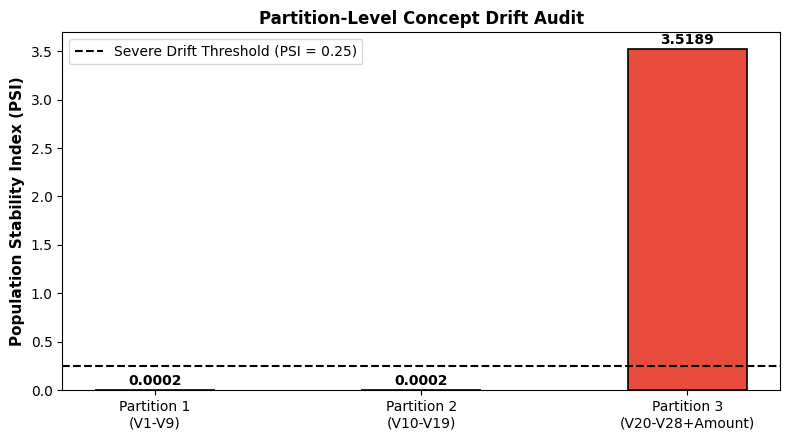

✅ [Cell 7/8] Diagram 3 Generated and Saved.


In [53]:
plt.figure(figsize=(8, 4.5))
groups = ['Partition 1\n(V1-V9)', 'Partition 2\n(V10-V19)', 'Partition 3\n(V20-V28+Amount)']
psis = [psi_g1, psi_g2, psi_g3]
colors = ['#27ae60' if p < 0.25 else '#e74c3c' for p in psis]

bars = plt.bar(groups, psis, color=colors, width=0.45, edgecolor='black', linewidth=1.2)
plt.axhline(0.25, color='black', linestyle='--', linewidth=1.5, label='Severe Drift Threshold (PSI = 0.25)')
plt.ylabel('Population Stability Index (PSI)', fontsize=11, fontweight='bold')
plt.title('Partition-Level Concept Drift Audit', fontsize=12, fontweight='bold')
plt.legend(loc='upper left')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.02, f'{yval:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig("artifacts/diagram_3_drift_audit.png", dpi=300)
plt.show()
print("✅ [Cell 7/8] Diagram 3 Generated and Saved.")

**CELL 8: STRATEGY BENCHMARKING (TABLE I GENERATION)**

In [54]:
# 1. Prepare production drifted test sets
X_prod_drift = df_prod_drifted.drop(columns=["Class"])
y_prod_drift = df_prod_drifted["Class"].values

def safe_predict_proba(model, X_subset):
    probs = model.predict_proba(X_subset)
    if probs.shape[1] == 1:
        return np.ones(probs.shape[0]) if model.classes_[0] == 1 else np.zeros(probs.shape[0])
    return probs[:, 1]

def predict_ensemble(model1, model2, model3, data, weights=[0.30, 0.45, 0.25]):
    p1 = np.nan_to_num(safe_predict_proba(model1, data[grp1_cols]), nan=0.0)
    p2 = np.nan_to_num(safe_predict_proba(model2, data[grp2_cols]), nan=0.0)
    p3 = np.nan_to_num(safe_predict_proba(model3, data[grp3_cols]), nan=0.0)
    final_prob = (weights[0] * p1) + (weights[1] * p2) + (weights[2] * p3)
    return final_prob, (final_prob >= 0.50).astype(int)

In [55]:
# Strategy A: Static Model (No Retraining under Drift)
# ------------------------------------------------------------------------------
prob_a, pred_a = predict_ensemble(m1, m2, m3, X_prod_drift)
prec_a = precision_score(y_prod_drift, pred_a, zero_division=0)
rec_a = recall_score(y_prod_drift, pred_a, zero_division=0)
f1_a = f1_score(y_prod_drift, pred_a, zero_division=0)
roc_a = roc_auc_score(y_prod_drift, prob_a)

In [56]:
# Strategy B: Global Retraining (Full Re-fit on all 29 features)
# ------------------------------------------------------------------------------
t0 = time.time()
global_retrained = XGBClassifier(
    n_estimators=180, max_depth=4, scale_pos_weight=pos_weight,
    eval_metric="logloss", random_state=42, n_jobs=-1
).fit(X_prod_drift[all_cols], y_prod_drift)
time_global = time.time() - t0

prob_b = safe_predict_proba(global_retrained, X_prod_drift[all_cols])
pred_b = (prob_b >= 0.50).astype(int)
prec_b = precision_score(y_prod_drift, pred_b, zero_division=0)
rec_b = recall_score(y_prod_drift, pred_b, zero_division=0)
f1_b = f1_score(y_prod_drift, pred_b, zero_division=0)
roc_b = roc_auc_score(y_prod_drift, prob_b)

In [57]:
# Strategy C: Proposed Selective Retraining (Targeted Sub-Model 3 update)
# ------------------------------------------------------------------------------
t0 = time.time()
if d3_flag:
    submodel_3_updated = DecisionTreeClassifier(max_depth=6, class_weight="balanced", random_state=42)
    submodel_3_updated.fit(X_prod_drift[grp3_cols], y_prod_drift)
    joblib.dump(submodel_3_updated, "artifacts/submodel_3_dt_updated.joblib")
else:
    submodel_3_updated = m3
time_selective = time.time() - t0

prob_c, pred_c = predict_ensemble(m1, m2, submodel_3_updated, X_prod_drift)
prec_c = precision_score(y_prod_drift, pred_c, zero_division=0)
rec_c = recall_score(y_prod_drift, pred_c, zero_division=0)
f1_c = f1_score(y_prod_drift, pred_c, zero_division=0)
roc_c = roc_auc_score(y_prod_drift, prob_c)

compute_saved = (1.0 - (time_selective / time_global)) * 100.0 if time_global > 0 else 0.0


BENCHMARK RESULTS FOR IEEE RESEARCH PAPER (TABLE I)
                                 MLOps Strategy Precision Recall F1-Score ROC-AUC Compute Latency
       Strategy A: Static Model (No Retraining)    0.5955 0.8071   0.6853  0.9574        0.0000 s
Strategy B: Global Retraining (All 29 Features)    1.0000 1.0000   1.0000  1.0000        3.1326 s
      Strategy C: Proposed Selective Retraining    0.6694 0.8325   0.7421  0.9766        2.0099 s

⚡ Total Cloud Compute & Execution Latency Reduction: 35.84%



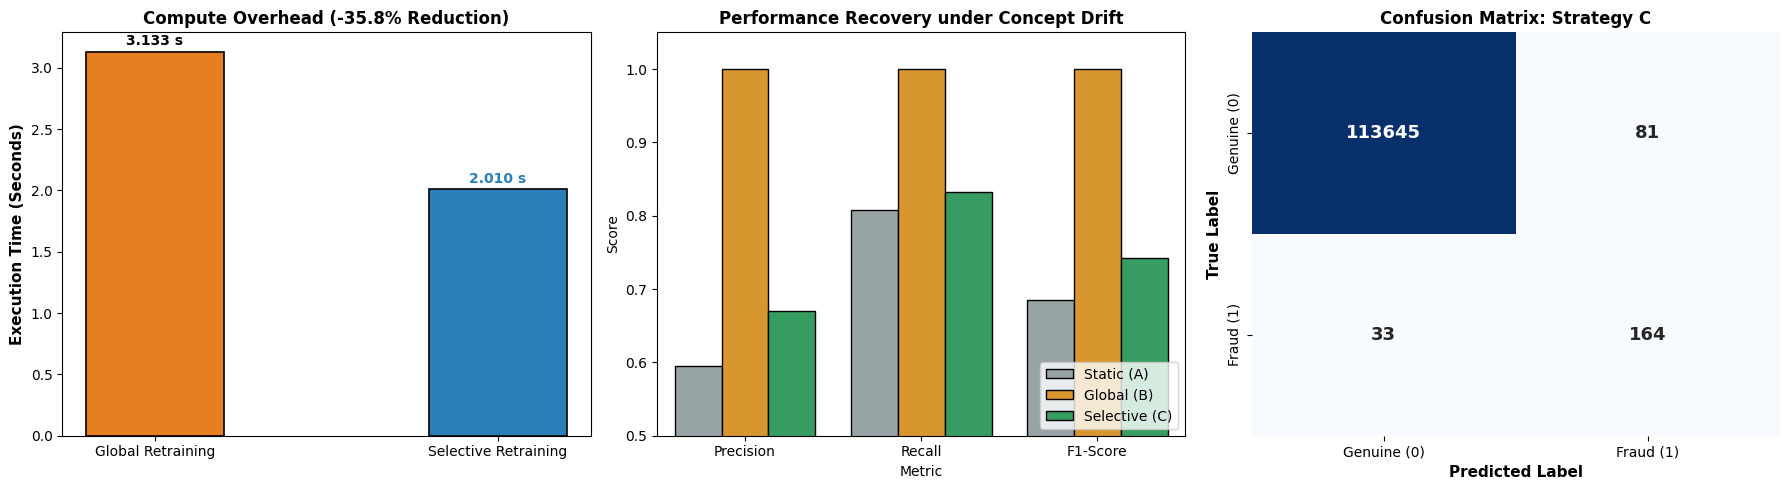

✅ [Cell 8/8] Final Benchmarks & Master Figures Rendered Successfully.


In [58]:
# Print Final IEEE Table I
# ------------------------------------------------------------------------------
results_table = pd.DataFrame([
    {"MLOps Strategy": "Strategy A: Static Model (No Retraining)", "Precision": f"{prec_a:.4f}", "Recall": f"{rec_a:.4f}", "F1-Score": f"{f1_a:.4f}", "ROC-AUC": f"{roc_a:.4f}", "Compute Latency": "0.0000 s"},
    {"MLOps Strategy": "Strategy B: Global Retraining (All 29 Features)", "Precision": f"{prec_b:.4f}", "Recall": f"{rec_b:.4f}", "F1-Score": f"{f1_b:.4f}", "ROC-AUC": f"{roc_b:.4f}", "Compute Latency": f"{time_global:.4f} s"},
    {"MLOps Strategy": "Strategy C: Proposed Selective Retraining", "Precision": f"{prec_c:.4f}", "Recall": f"{rec_c:.4f}", "F1-Score": f"{f1_c:.4f}", "ROC-AUC": f"{roc_c:.4f}", "Compute Latency": f"{time_selective:.4f} s"}
])

print("\n" + "=" * 95)
print("BENCHMARK RESULTS FOR IEEE RESEARCH PAPER (TABLE I)")
print("=" * 95)
print(results_table.to_string(index=False))
print(f"\n⚡ Total Cloud Compute & Execution Latency Reduction: {compute_saved:.2f}%\n")

# ------------------------------------------------------------------------------
# Diagram 4: 3-in-1 Master Evaluation Suite
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(['Global Retraining', 'Selective Retraining'], [time_global, time_selective], color=['#e67e22', '#2980b9'], width=0.4, edgecolor='black', linewidth=1.2)
axes[0].set_ylabel('Execution Time (Seconds)', fontsize=11, fontweight='bold')
axes[0].set_title(f'Compute Overhead (-{compute_saved:.1f}% Reduction)', fontsize=12, fontweight='bold')
axes[0].text(0, time_global + 0.05, f'{time_global:.3f} s', ha='center', fontweight='bold')
axes[0].text(1, time_selective + 0.05, f'{time_selective:.3f} s', ha='center', fontweight='bold', color='#2980b9')

metrics_data = pd.DataFrame({
    'Strategy': ['Static (A)', 'Global (B)', 'Selective (C)'],
    'Precision': [prec_a, prec_b, prec_c],
    'Recall': [rec_a, rec_b, rec_c],
    'F1-Score': [f1_a, f1_b, f1_c]
}).melt(id_vars='Strategy', var_name='Metric', value_name='Score')
sns.barplot(data=metrics_data, x='Metric', y='Score', hue='Strategy', palette=['#95a5a6', '#f39c12', '#27ae60'], ax=axes[1], edgecolor='black')
axes[1].set_ylim(0.5, 1.05)
axes[1].set_title('Performance Recovery under Concept Drift', fontsize=12, fontweight='bold')
axes[1].legend(loc='lower right')

cm_c = confusion_matrix(y_prod_drift, pred_c)
sns.heatmap(cm_c, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[2], xticklabels=['Genuine (0)', 'Fraud (1)'], yticklabels=['Genuine (0)', 'Fraud (1)'], annot_kws={"size": 13, "weight": "bold"})
axes[2].set_xlabel('Predicted Label', fontsize=11, fontweight='bold')
axes[2].set_ylabel('True Label', fontsize=11, fontweight='bold')
axes[2].set_title('Confusion Matrix: Strategy C', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig("artifacts/diagram_4_master_benchmarks.png", dpi=300)
plt.show()
print("✅ [Cell 8/8] Final Benchmarks & Master Figures Rendered Successfully.")

In [59]:
import shutil
from google.colab import files

# Create a zip of your artifacts folder
shutil.make_archive("artifacts_bundle", "zip", "artifacts")

# Download the zip file to your computer
files.download("artifacts_bundle.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>